In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
x_ = np.linspace(0, 10, 100)
y_ = 3.1234 * x_ - 12.2 + np.random.normal(10, 3, size=(100,))

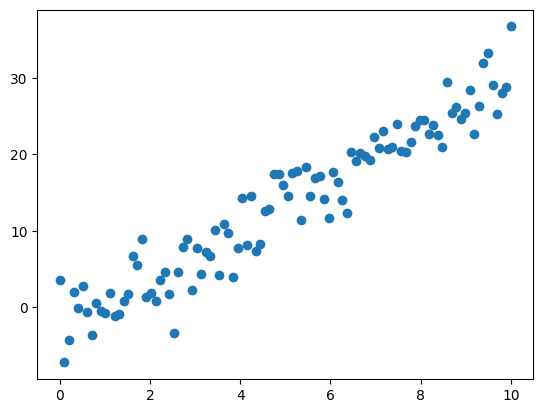

In [30]:
plt.scatter(x_, y_)

In [31]:
class KalmanFilter:
    def __init__(self, z_0, Q, R, A, C, P_0):
        self.z = z_0
        self.Q = Q
        self.R = R
        self.A = A
        self.C = C
        self.P = P_0

    def predict (self):
        self.z = self.A @ self.z
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.z.copy()
    
    def estimate(self, x):
        y_hat = self.C @ self.z
        residuals = x - y_hat

        kalman_gain = self.P @ self.C.T @ np.linalg.inv(self.C @ self.P @ self.C.T + self.R)
        self.P = (np.eye(2) - kalman_gain @ self.C) @ self.P
        
        self.z = self.z + kalman_gain @ residuals
        return self.z.copy()

z_0 = np.array([[0, 0]]).reshape(-1, 1)
P_0 = 0.1 * np.eye(2)
Q = np.eye(2) * 0.1
R = np.eye(1) * 1
A = np.eye(2)
C = np.array([[1, 0]]).reshape(1, -1)

kalman_filter = KalmanFilter(z_0, Q, R, A, C, P_0)

In [32]:
coefs = []
preds = []

for (xi, yi) in zip(x_, y_):
    C = np.array([[1, xi]]).reshape(1, -1)
    kalman_filter.C = C

    # Predict
    kalman_filter.predict()

    # Estimate
    z_hat = kalman_filter.estimate(np.array([[yi]]).reshape(1, 1))
    coefs.append(z_hat)
    preds.append((C @ z_hat)[0, 0])

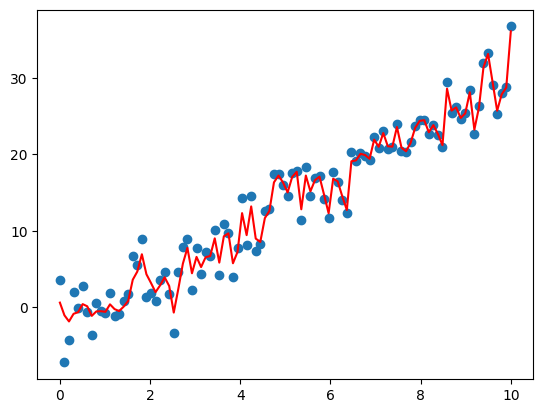

In [33]:
plt.scatter(x_, y_)
plt.plot(x_, preds, c = 'r')